<!-- launch-badges -->
<a href="https://colab.research.google.com/github/laban254/ml-for-infrastructure/blob/main/05_sre_applications/log_analysis/log_clustering.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
&nbsp;
<a href="https://mybinder.org/v2/gh/laban254/ml-for-infrastructure/main?urlpath=lab/tree/05_sre_applications/log_analysis/log_clustering.ipynb" target="_blank"><img src="https://mybinder.org/badge_logo.svg" alt="Open in Binder"/></a>

> ▶️ **Run this notebook live** — no install needed. Click a badge above to open it in a free cloud runtime.

# Intelligent Log Grouping and Clustering

## Objectives
- Transform unstructured system logs (text) into numerical features using **TF-IDF**.
- Apply **K-Means Clustering** to automatically group similar error messages, ignoring dynamic variables like timestamps, IPs, or process IDs.

## Dataset
- A curated list of raw server log lines (synthetic but realistic) simulating a fast-moving production environment.

## Expected Outcome
- Given thousands of messy log lines, the model will automatically surface the handful of "root cause" categories — and even **auto-name** them — saving hours of manual `grep` work.

## What this notebook builds
- TF-IDF + K-Means to group logs, **silhouette analysis** to choose `k` automatically, **auto-naming** of each cluster from its keywords, and live routing of new logs. The closing "try it yourself" exercise then walks through extending this into a novelty detector for unseen failure modes.

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import re

pd.set_option('display.max_colwidth', None)

### 1. Generating Raw Log Data
In production, logs contain dynamic data (like IDs or IPs) that confuse simple text-matching. We need to group log lines that are *structurally* similar.

In [2]:
import random
random.seed(42)

# Realistic log "templates" with dynamic fields (IPs, IDs, paths, percentages).
# In a real system these come from your logging pipeline; here we synthesise a
# fast-moving stream so the clustering has something meaningful to group.
templates = [
    lambda: f"ERROR: Connection timeout calling backend service at 10.0.{random.randint(0,9)}.{random.randint(1,254)}:8080",
    lambda: f"INFO: User {random.randint(1000,9999)} logged in successfully from 192.168.{random.randint(0,5)}.{random.randint(1,254)}",
    lambda: f"ERROR: OutOfMemoryError: Java heap space thread id {random.randint(100,999)}",
    lambda: f"WARN: High memory usage detected on node worker-{random.randint(1,8)} ({random.randint(80,99)}%)",
    lambda: f"ERROR: Database connection failed (FATAL: remaining connection slots are reserved for superuser connections)",
    lambda: f"INFO: Request completed GET /api/v1/orders/{random.randint(1,9999)} in {random.randint(5,90)}ms status 200",
    lambda: f"ERROR: 500 Internal Server Error on endpoint /api/v1/checkout/{random.randint(1,9999)}",
    lambda: f"WARN: Disk usage high on /dev/sda{random.randint(1,4)} ({random.randint(85,99)}%)",
]
# Weight the templates so some failure modes are far more common than others
weights = [25, 30, 8, 12, 4, 28, 6, 7]

N = 4000
raw_logs = [
    f"[2025-02-25 10:{random.randint(0,59):02d}:{random.randint(0,59):02d}] " + random.choices(templates, weights=weights)[0]()
    for _ in range(N)
]

df = pd.DataFrame({'raw_log': raw_logs})
print(f"Total logs to process: {len(df):,}")
df['raw_log'].head(5).tolist()

Total logs to process: 4,000


['[2025-02-25 10:40:07] ERROR: Connection timeout calling backend service at 10.0.4.63:8080',
 '[2025-02-25 10:14:08] INFO: Request completed GET /api/v1/orders/8936 in 16ms status 200',
 '[2025-02-25 10:37:27] ERROR: Connection timeout calling backend service at 10.0.1.56:8080',
 '[2025-02-25 10:14:32] WARN: High memory usage detected on node worker-4 (97%)',
 '[2025-02-25 10:26:14] INFO: User 5557 logged in successfully from 192.168.0.195']

### 2. Preprocessing / Log Parsing
Before clustering, it's best practice to strip out digits, IPs, and timestamps so the algorithm focuses on the "skeleton" of the message.

In [3]:
def clean_log(log_line):
    # Remove timestamps [2025...]
    log_line = re.sub(r'\[.*?\]', '', log_line)
    # Remove IP addresses
    log_line = re.sub(r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}(:\d+)?\b', '<IP>', log_line)
    # Remove standalone numbers (user IDs, thread IDs, percentages)
    log_line = re.sub(r'\b\d+\%?\b', '<NUM>', log_line)
    
    return log_line.strip()

df['cleaned_log'] = df['raw_log'].apply(clean_log)
df[['raw_log', 'cleaned_log']].head(3)

,raw_log,cleaned_log
0,[2025-02-25 10:40:07] ERROR: Connection timeout calling backend service at 10.0.4.63:8080,ERROR: Connection timeout calling backend service at <IP>
1,[2025-02-25 10:14:08] INFO: Request completed GET /api/v1/orders/8936 in 16ms status 200,INFO: Request completed GET /api/v1/orders/<NUM> in 16ms status <NUM>
2,[2025-02-25 10:37:27] ERROR: Connection timeout calling backend service at 10.0.1.56:8080,ERROR: Connection timeout calling backend service at <IP>


### 3. Feature Extraction (TF-IDF)
TF-IDF translates our text into a matrix of numbers, weighing rare words (like "OutOfMemoryError") higher than common words (like "at" or "from").

In [4]:
vectorizer = TfidfVectorizer(max_features=50, stop_words='english')
X = vectorizer.fit_transform(df['cleaned_log'])
print(f"TF-IDF Matrix shape: {X.shape}")

TF-IDF Matrix shape: (4000, 50)


### 4. K-Means Clustering
We group the logs into `k=5` clusters.

In [5]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

# Look at the clusters!
grouped = df.groupby('cluster')

for name, group in grouped:
    print(f"\n--- Cluster {name} ({len(group)} logs) ---")
    # Show one representative example from this cluster
    print(group['cleaned_log'].iloc[0])


--- Cluster 0 (472 logs) ---
ERROR: <NUM> Internal Server Error on endpoint /api/v1/checkout/<NUM>

--- Cluster 1 (963 logs) ---
ERROR: Connection timeout calling backend service at <IP>

--- Cluster 2 (954 logs) ---
INFO: User <NUM> logged in successfully from <IP>

--- Cluster 3 (969 logs) ---
INFO: Request completed GET /api/v1/orders/<NUM> in 16ms status <NUM>

--- Cluster 4 (642 logs) ---
WARN: High memory usage detected on node worker-<NUM> (<NUM>%)


### 5. Choosing `k` automatically (Elbow + Silhouette)

We guessed `k=5` above. In production you don't want to guess — the number of distinct failure modes changes over time. Two standard tools:

- **Elbow**: plot inertia (within-cluster spread) vs `k`; the "elbow" is the point of diminishing returns.
- **Silhouette**: measures how cleanly separated the clusters are (higher is better, max 1.0). We pick the `k` with the best silhouette.

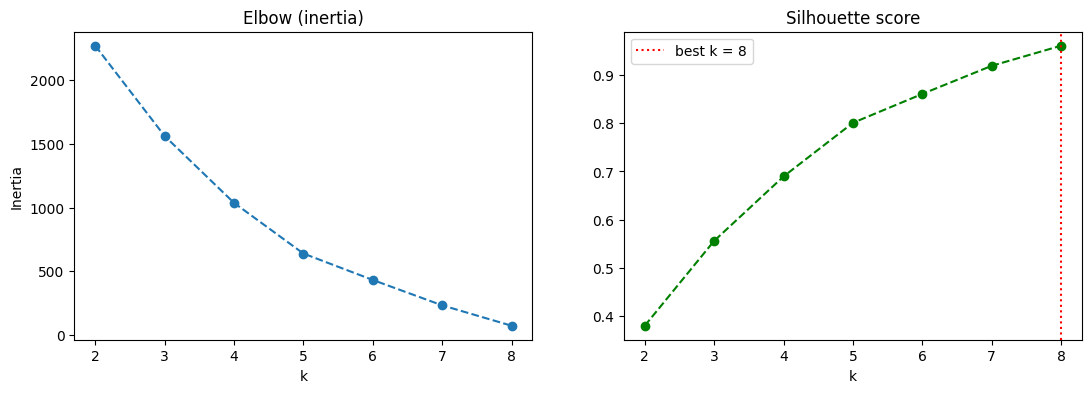

Silhouette suggests k = 8


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

K_range = range(2, 9)
inertias, silhouettes = [], []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, km.labels_))

best_k = K_range[int(np.argmax(silhouettes))]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(list(K_range), inertias, 'o--'); ax[0].set_title('Elbow (inertia)')
ax[0].set_xlabel('k'); ax[0].set_ylabel('Inertia')
ax[1].plot(list(K_range), silhouettes, 'o--', color='green')
ax[1].axvline(best_k, color='red', ls=':', label=f'best k = {best_k}')
ax[1].set_title('Silhouette score'); ax[1].set_xlabel('k'); ax[1].legend()
plt.show()
print(f'Silhouette suggests k = {best_k}')

### 6. Auto-naming the clusters (the real payoff)

A cluster number (`3`) means nothing to an on-call engineer. Let's turn each cluster into a **human-readable category** by reading the highest-weighted TF-IDF terms at its centre — then count how many logs fall into each. That bar chart is effectively an *automatic incident summary*.

Top keywords per cluster:
  cluster 0: logged / user / successfully
  cluster 1: num / completed / orders
  cluster 2: backend / calling / timeout
  cluster 3: worker / node / detected
  cluster 4: id / thread / outofmemoryerror
  cluster 5: error / server / endpoint
  cluster 6: connection / superuser / connections
  cluster 7: dev / disk / warn


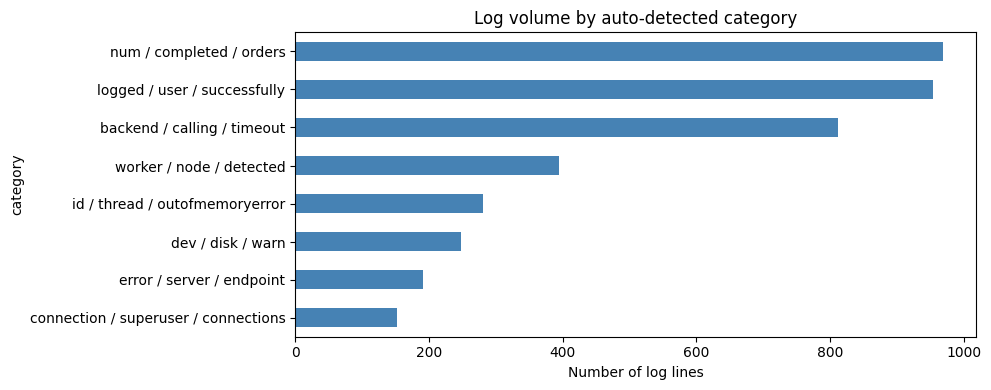

In [7]:
import numpy as np

# Refit with the data-driven k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

terms = vectorizer.get_feature_names_out()
centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

def name_cluster(cluster_id, n_terms=3):
    top = [terms[i] for i in centroids[cluster_id, :n_terms]]
    return ' / '.join(top)

cluster_names = {cid: name_cluster(cid) for cid in range(best_k)}
df['category'] = df['cluster'].map(cluster_names)

volumes = df['category'].value_counts()
print('Top keywords per cluster:')
for cid, nm in cluster_names.items():
    print(f'  cluster {cid}: {nm}')

plt.figure(figsize=(10, 4))
volumes.plot(kind='barh', color='steelblue')
plt.title('Log volume by auto-detected category')
plt.xlabel('Number of log lines'); plt.gca().invert_yaxis(); plt.tight_layout()
plt.show()

### 7. Routing a brand-new log line

Once the model is trained, classifying a *new* log is instant — exactly what a real-time pipeline needs to tag every incoming line and spot which failure category is suddenly spiking.

In [8]:
def classify_log(line: str) -> str:
    cleaned = clean_log(line)
    vec = vectorizer.transform([cleaned])
    cid = kmeans.predict(vec)[0]
    return cluster_names[cid]

for sample in [
    '[2025-02-25 11:02:09] ERROR: Connection timeout calling backend service at 10.0.7.42:8080',
    '[2025-02-25 11:02:11] ERROR: OutOfMemoryError: Java heap space thread id 274',
    '[2025-02-25 11:02:13] INFO: User 4821 logged in successfully from 192.168.2.9',
]:
    print(f'{sample[:55]}...  ->  [{classify_log(sample)}]')

[2025-02-25 11:02:09] ERROR: Connection timeout calling...  ->  [backend / calling / timeout]
[2025-02-25 11:02:11] ERROR: OutOfMemoryError: Java hea...  ->  [id / thread / outofmemoryerror]
[2025-02-25 11:02:13] INFO: User 4821 logged in success...  ->  [logged / user / successfully]


## 📝 Exercise: detect a *novel* failure mode

Clustering assigns every log to its nearest cluster — even a log that doesn't really belong to any of them. A brand-new outage might be silently absorbed into an existing bucket. **Use the distance to the nearest centroid** (`kmeans.transform`) to flag logs that are suspiciously far from every cluster centre — these are your candidate *unknown* incidents.

```python
# your code here
# hint: kmeans.transform(vec).min() gives distance to the closest centroid
```

<details><summary>💡 Reveal solution</summary>

```python
novel = '[2025-02-25 11:30:00] FATAL: kernel panic - not syncing: VFS unable to mount root fs'
vec = vectorizer.transform([clean_log(novel)])
dist = kmeans.transform(vec).min()
typical = kmeans.transform(X).min(axis=1)
cutoff = typical.mean() + 3 * typical.std()
print(f'distance={dist:.3f}  cutoff={cutoff:.3f}  -> ' + ('NOVEL incident' if dist > cutoff else 'known category'))
```

A log that is far from *every* centroid is exactly what you want to page a human about — it's something the system has never seen before.
</details>